# 02b - Confusion-Driven Improvement Notebook

This notebook is the next step after `02_ocr_text_plus_layout_features.ipynb`.
It consumes saved predictions from notebook 02, analyzes confusion pairs, and builds a targeted specialist pipeline to improve the hardest errors.


## Leakage-Safe Protocol

- Use existing `train/val/test` split only.
- Use validation set for routing/tuning decisions.
- Use test set once for final reporting.
- No vectorizer/scaler fit on validation or test.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import load_ocr_config
from src.ocr_engine import load_ocr_text
from src.evaluation import compute_metrics, metrics_dict_to_frame, confusion_matrix_df, plot_confusion_matrix


In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

LABELS = ['invoice', 'form', 'resume', 'email', 'budget']
SPECIALIST_LABELS = ['invoice', 'form', 'budget']

cfg = load_ocr_config(PROJECT_ROOT / 'configs' / 'config.yaml')
cfg.cache_dir = str(PROJECT_ROOT / 'data' / 'interim' / 'ocr')

pred_dir = PROJECT_ROOT / 'outputs' / 'predictions'
fig_dir = PROJECT_ROOT / 'reports' / 'figures'
table_dir = PROJECT_ROOT / 'reports' / 'tables'
model_dir = PROJECT_ROOT / 'models' / 'layout'

for p in [pred_dir, fig_dir, table_dir, model_dir]:
    p.mkdir(parents=True, exist_ok=True)


## 1) Load Predictions from Notebook 02


In [3]:
val_preds = {
    'text_only': pd.read_csv(pred_dir / 'text_only_val_predictions.csv'),
    'layout_only': pd.read_csv(pred_dir / 'layout_only_val_predictions.csv'),
    'text_layout': pd.read_csv(pred_dir / 'text_layout_val_predictions.csv'),
}

test_preds = {
    'text_only': pd.read_csv(pred_dir / 'text_only_test_predictions.csv'),
    'layout_only': pd.read_csv(pred_dir / 'layout_only_test_predictions.csv'),
    'text_layout': pd.read_csv(pred_dir / 'text_layout_test_predictions.csv'),
}

for name, df in val_preds.items():
    req = {'doc_id','true_label','pred_label'}
    if not req.issubset(df.columns):
        raise ValueError(f"{name} validation predictions missing required columns: {req - set(df.columns)}")

val_scores = []
for name, df in val_preds.items():
    m = compute_metrics(df['true_label'].values, df['pred_label'].values, LABELS)
    row = metrics_dict_to_frame(m, name, 'val').iloc[0].to_dict()
    val_scores.append(row)

val_table = pd.DataFrame(val_scores).sort_values('macro_f1', ascending=False).reset_index(drop=True)
val_table


,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
0,text_only,val,0.879384,0.880271,0.880817,0.772059,0.849057,0.869806,0.835106,1.000000,0.965879,0.980663,0.939153,0.791123,0.805851,0.772059,0.849057
1,text_layout,val,0.866100,0.866924,0.867490,0.772727,0.824798,0.872464,0.800532,0.991870,0.960630,0.964865,0.944444,0.746269,0.797872,0.772727,0.824798
2,layout_only,val,0.804463,0.805669,0.806343,0.694236,0.746631,0.756983,0.720745,0.942466,0.902887,0.953039,0.912698,0.695980,0.736702,0.694236,0.746631


In [4]:
best_base_model = val_table.iloc[0]['model_name']
print('Best base model by validation macro_f1:', best_base_model)

val_base = val_preds[best_base_model].copy()
test_base = test_preds[best_base_model].copy()


Best base model by validation macro_f1: text_only


## 2) Confusion Pair Analysis (from Base Model)


In [5]:
def confusion_pair_counts(df, pairs):
    rows = []
    for t, p in pairs:
        cnt = int(((df['true_label'] == t) & (df['pred_label'] == p)).sum())
        rows.append({'true_class': t, 'pred_class': p, 'count': cnt})
    return pd.DataFrame(rows).sort_values('count', ascending=False).reset_index(drop=True)

focus_pairs = [
    ('invoice', 'budget'),
    ('budget', 'invoice'),
    ('invoice', 'form'),
    ('form', 'invoice'),
    ('email', 'resume'),
    ('resume', 'email'),
]

val_pair_table = confusion_pair_counts(val_base, focus_pairs)
test_pair_table = confusion_pair_counts(test_base, focus_pairs)

print('Validation confusion pairs:')
display(val_pair_table)
print('Test confusion pairs:')
display(test_pair_table)

val_pair_table.to_csv(table_dir / '02b_val_confusion_pairs.csv', index=False)
test_pair_table.to_csv(table_dir / '02b_test_confusion_pairs.csv', index=False)


Validation confusion pairs:


,true_class,pred_class,count
0,budget,invoice,51
1,invoice,budget,42
2,form,invoice,29
3,invoice,form,14
4,resume,email,1
5,email,resume,0


Test confusion pairs:


,true_class,pred_class,count
0,budget,invoice,44
1,invoice,budget,43
2,form,invoice,24
3,invoice,form,16
4,resume,email,3
5,email,resume,0


## 3) Load OCR Text and Inspect Hard Examples


In [6]:
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'train.csv')
val_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'val.csv')
test_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'test.csv')

for df, split in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
    if 'split' not in df.columns:
        df['split'] = split


def attach_ocr_text(df):
    out = df.copy()
    out['ocr_text'] = out['doc_id'].map(lambda d: load_ocr_text(d, cfg=cfg))
    out['ocr_text'] = out['ocr_text'].fillna('')
    return out

train_text = attach_ocr_text(train_df)
val_text = attach_ocr_text(val_df)
test_text = attach_ocr_text(test_df)

val_join = val_base.merge(val_text[['doc_id', 'ocr_text']], on='doc_id', how='left')
test_join = test_base.merge(test_text[['doc_id', 'ocr_text']], on='doc_id', how='left')

preview_rows = []
for t, p in [('invoice', 'budget'), ('invoice', 'form'), ('email', 'resume')]:
    subset = test_join[(test_join['true_label'] == t) & (test_join['pred_label'] == p)].head(5)
    for _, r in subset.iterrows():
        preview_rows.append({
            'pair': f'{t}->{p}',
            'doc_id': r['doc_id'],
            'snippet': (r.get('ocr_text') or '')[:600].replace('\n', ' ')
        })

preview_df = pd.DataFrame(preview_rows)
preview_df.to_csv(table_dir / '02b_error_snippets.csv', index=False)
preview_df.head(10)


,pair,doc_id,snippet
0,invoice->budget,doc_00035043,Eine 5 ' cate + saa Hi & sr z Ee i E gs : E gz...
1,invoice->budget,doc_00035076,"FE Chay Maye - : ReGisTe, .? F 28g ee nee | . ..."
2,invoice->budget,doc_00035115,"SEL,"
3,invoice->budget,doc_00035119,Fewest NL Lo doy or | — ee SPA eee + Rae te ee...
4,invoice->budget,doc_00035126,|
5,invoice->form,doc_00035045,24.89 02:48 PM 7 POT PROMOTIONAL MARKETING TNC...
6,invoice->form,doc_00035173,——— ———————————————————————————_—________—_———...
7,invoice->form,doc_00035321,. ae entneanmennactetinnmninnaseetntoraee tn s...
8,invoice->form,doc_00035500,"{ ~ REIMBURSEMENT, AND EXPENSE DRAFT fs wavaoe..."
9,invoice->form,doc_00035505,Llc! ee bn | Boe | CSN eee SCALA eee = MEINGO ...


## 4) Train a Specialist for Financial/Admin Confusions (`invoice`, `form`, `budget`)

We keep your base model unchanged. We only learn a specialist that is applied when base prediction is uncertain in this branch.


In [7]:
train_fin = train_text[train_text['class_name'].isin(SPECIALIST_LABELS)].copy()
val_fin = val_text[val_text['class_name'].isin(SPECIALIST_LABELS)].copy()
test_fin = test_text[test_text['class_name'].isin(SPECIALIST_LABELS)].copy()
def normalize_text(s):
    return ' '.join(str(s).lower().split())
x_train_fin = train_fin['ocr_text'].map(normalize_text).tolist()
y_train_fin = train_fin['class_name'].values
x_val_fin = val_fin['ocr_text'].map(normalize_text).tolist()
y_val_fin = val_fin['class_name'].values
search_grid = []
for word_ng in [(1,2), (1,3)]:
    for char_ng in [(3,5), (3,6)]:
        for min_df in [1,2,3]:
            for C in [0.5,1.0,2.0,4.0]:
                search_grid.append((word_ng, char_ng, min_df, C))
best = {'macro_f1': -1.0, 'cfg': None, 'wv': None, 'cv': None, 'model': None, 'val_pred': None, 'val_proba': None}
for word_ng, char_ng, min_df, C in search_grid:
    try:
        wv = TfidfVectorizer(analyzer='word', ngram_range=word_ng, min_df=min_df, max_features=80000, sublinear_tf=True)
        cv = TfidfVectorizer(analyzer='char_wb', ngram_range=char_ng, min_df=min_df, max_features=120000, sublinear_tf=True)
        Xw_train = wv.fit_transform(x_train_fin)
        Xc_train = cv.fit_transform(x_train_fin)
        X_train = sparse.hstack([Xw_train, Xc_train], format='csr')
        Xw_val = wv.transform(x_val_fin)
        Xc_val = cv.transform(x_val_fin)
        X_val = sparse.hstack([Xw_val, Xc_val], format='csr')
        clf = LogisticRegression(max_iter=3500, solver='saga', C=C, class_weight='balanced', random_state=RANDOM_STATE)
        clf.fit(X_train, y_train_fin)
        y_pred_val = clf.predict(X_val)
        m = compute_metrics(y_val_fin, y_pred_val, SPECIALIST_LABELS)
        if m['macro_f1'] > best['macro_f1']:
            best.update({
                'macro_f1': m['macro_f1'],
                'cfg': {'word_ngram': word_ng, 'char_ngram': char_ng, 'min_df': min_df, 'C': C},
                'wv': wv, 'cv': cv, 'model': clf,
                'val_pred': y_pred_val,
                'val_proba': clf.predict_proba(X_val)
            })
    except Exception:
        continue
if best['model'] is None:
    raise RuntimeError('Specialist training failed for all configs.')
best['cfg']


{'word_ngram': (1, 3), 'char_ngram': (3, 6), 'min_df': 2, 'C': 4.0}

## 5) Validation Tuning for Routing Rule

Routing condition:
- base model prediction is in `{invoice, form, budget}`
- AND confidence is low OR top-2 margin is small

We tune thresholds on validation only.


In [8]:
# Build specialist features for full val/test docs
def specialist_predict_for_docs(text_series, wv, cv, model):
    x = text_series.map(lambda s: ' '.join(str(s).lower().split())).tolist()
    X = sparse.hstack([wv.transform(x), cv.transform(x)], format='csr')
    pred = model.predict(X)
    proba = model.predict_proba(X)
    cls = list(model.classes_)
    return pred, proba, cls
val_spec_pred, val_spec_proba, spec_classes = specialist_predict_for_docs(val_text['ocr_text'], best['wv'], best['cv'], best['model'])
test_spec_pred, test_spec_proba, _ = specialist_predict_for_docs(test_text['ocr_text'], best['wv'], best['cv'], best['model'])
val_hybrid = val_base.merge(val_text[['doc_id']], on='doc_id', how='left').copy()
val_hybrid['spec_pred'] = val_spec_pred
test_hybrid = test_base.merge(test_text[['doc_id']], on='doc_id', how='left').copy()
test_hybrid['spec_pred'] = test_spec_pred
conf_cols = [c for c in val_base.columns if c.startswith('confidence_')]
if not conf_cols:
    raise RuntimeError('Base prediction files must contain class confidence columns.')
def apply_routing(df, conf_threshold, margin_threshold):
    out = df.copy()
    probs = out[conf_cols].to_numpy()
    sorted_probs = np.sort(probs, axis=1)
    top1 = sorted_probs[:, -1]
    top2 = sorted_probs[:, -2]
    margin = top1 - top2
    in_branch = out['pred_label'].isin(SPECIALIST_LABELS)
    uncertain = (top1 < conf_threshold) | (margin < margin_threshold)
    route = in_branch & uncertain
    out['routed_to_specialist'] = route
    out['pred_label_final'] = np.where(route, out['spec_pred'], out['pred_label'])
    out['top1_confidence'] = top1
    out['top2_margin'] = margin
    return out
best_route = {'score': -1e9, 'conf_threshold': None, 'margin_threshold': None, 'metrics': None, 'df': None}
for conf_th in [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    for margin_th in [0.03, 0.05, 0.08, 0.10, 0.12, 0.15]:
        tmp = apply_routing(val_hybrid, conf_th, margin_th)
        m = compute_metrics(tmp['true_label'].values, tmp['pred_label_final'].values, LABELS)
        # prioritize invoice recall but keep macro quality
        score = m['macro_f1'] + 0.35 * m.get('invoice_recall', 0.0)
        if score > best_route['score']:
            best_route = {
                'score': score,
                'conf_threshold': conf_th,
                'margin_threshold': margin_th,
                'metrics': m,
                'df': tmp,
            }
best_route_summary = {
    'best_conf_threshold': best_route['conf_threshold'],
    'best_margin_threshold': best_route['margin_threshold'],
    'val_macro_f1': best_route['metrics']['macro_f1'],
    'val_invoice_recall': best_route['metrics']['invoice_recall'],
}
best_route_summary


{'best_conf_threshold': 0.5,
 'best_margin_threshold': 0.03,
 'val_macro_f1': 0.8834021734935884,
 'val_invoice_recall': 0.8544474393530997}

## 6) Final Test Evaluation (Base vs Confusion-Specialist Hybrid)


In [9]:
base_test_metrics = compute_metrics(test_base['true_label'].values, test_base['pred_label'].values, LABELS)

best_test = apply_routing(
    test_hybrid,
    conf_threshold=best_route['conf_threshold'],
    margin_threshold=best_route['margin_threshold'],
)

hybrid_test_metrics = compute_metrics(test_base['true_label'].values, best_test['pred_label_final'].values, LABELS)

comparison = pd.concat([
    metrics_dict_to_frame(base_test_metrics, f'{best_base_model}_base', 'test'),
    metrics_dict_to_frame(hybrid_test_metrics, f'{best_base_model}_plus_specialist', 'test'),
], ignore_index=True)
comparison


,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
0,text_only_base,test,0.876661,0.877511,0.877862,0.806701,0.841398,0.873239,0.824468,0.989071,0.952632,0.961957,0.938992,0.767327,0.824468,0.806701,0.841398
1,text_only_plus_specialist,test,0.879320,0.880104,0.880452,0.798489,0.852151,0.880342,0.821809,0.989071,0.952632,0.961957,0.938992,0.781955,0.829787,0.798489,0.852151


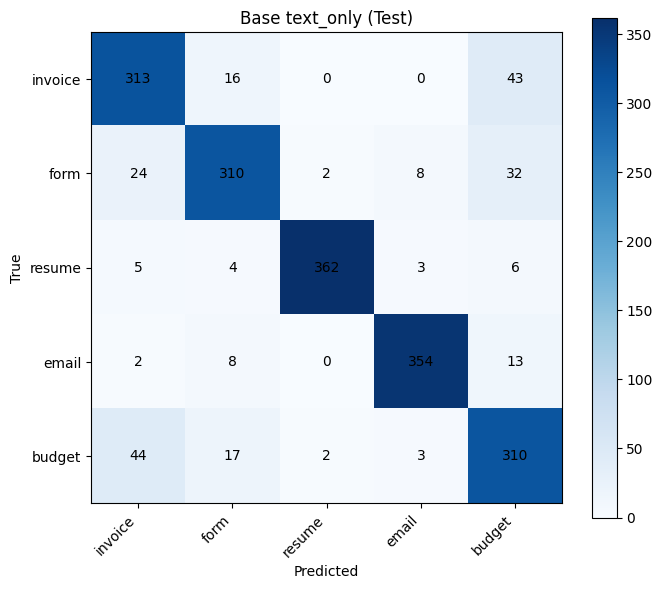

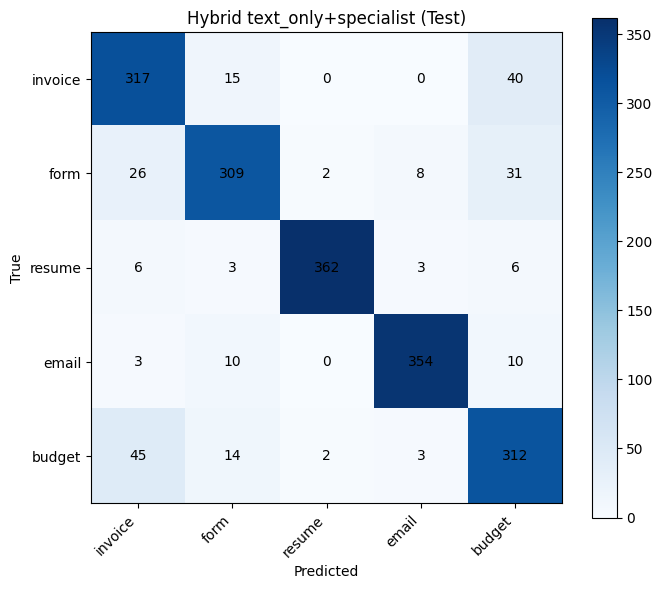

In [10]:
cm_base = confusion_matrix_df(test_base['true_label'].values, test_base['pred_label'].values, LABELS)
cm_hybrid = confusion_matrix_df(test_base['true_label'].values, best_test['pred_label_final'].values, LABELS)

plot_confusion_matrix(cm_base, f'Base {best_base_model} (Test)', save_path=fig_dir / '02b_cm_base_test.png')
plot_confusion_matrix(cm_hybrid, f'Hybrid {best_base_model}+specialist (Test)', save_path=fig_dir / '02b_cm_hybrid_test.png')


## 7) Save Artifacts


In [11]:
# Save predictions
best_test_out = best_test.copy()
best_test_out = best_test_out.rename(columns={'pred_label_final': 'pred_label'})
best_test_out.to_csv(pred_dir / f'02b_{best_base_model}_plus_specialist_test_predictions.csv', index=False)

best_val_out = best_route['df'].copy().rename(columns={'pred_label_final': 'pred_label'})
best_val_out.to_csv(pred_dir / f'02b_{best_base_model}_plus_specialist_val_predictions.csv', index=False)

# Save metrics
comparison.to_csv(table_dir / '02b_specialist_comparison_test.csv', index=False)

route_df = pd.DataFrame([best_route_summary])
route_df.to_csv(table_dir / '02b_specialist_routing_best_val.csv', index=False)

# Save specialist config
with open(model_dir / '02b_specialist_config.json', 'w', encoding='utf-8') as f:
    json.dump({
        'base_model': best_base_model,
        'specialist_labels': SPECIALIST_LABELS,
        'text_vectorizer': best['cfg'],
        'routing': best_route_summary,
    }, f, indent=2)

print('Saved 02b artifacts to predictions/tables/figures/models.')


Saved 02b artifacts to predictions/tables/figures/models.


## Conclusion

If hybrid improves `invoice_recall` (and ideally macro F1), keep this as your next candidate before final model comparison.
If gains are small, keep base text model and focus next on stronger layout features or hierarchical routing.
